# 01. EDA Stage Overview


## 그래프

1. Split 크기 비교
2. Digital stage 분포
3. Split별 stage 비율 비교
4. GROUP별 표본 분포
5. Stage별 GROUP 구성 비율 히트맵
6. YEAR별 stage 비율 비교
7. 디지털 단계별 연령대 분포
8. 디지털 단계별 학력 / 가구소득 구간 분포
9. 디지털 단계별 AI 경험 비교
10. 디지털 단계별 핵심 지표 요약
11. 디지털 활동 점수 단계별 분포

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["axes.unicode_minus"] = False
available_fonts = {f.name for f in fm.fontManager.ttflist}
font_candidates = ["NanumGothic", "AppleGothic", "Malgun Gothic", "DejaVu Sans"]
selected_font = next((font for font in font_candidates if font in available_fonts), "DejaVu Sans")
plt.rcParams["font.family"] = selected_font

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "labeled"
OUT_DIR = ROOT / "outputs" / "figures" / "eda_stage"
OUT_DIR.mkdir(parents=True, exist_ok=True)

STAGE_ORDER = ["1단계_완전_소외", "2단계_부분_적응", "3단계_자립_적응"]
STAGE_DISPLAY = {
    "1단계_완전_소외": "1단계\n완전 소외",
    "2단계_부분_적응": "2단계\n부분 적응",
    "3단계_자립_적응": "3단계\n자립 적응",
}
STAGE_COLORS = {
    "1단계_완전_소외": "#D95F5F",
    "2단계_부분_적응": "#F2B134",
    "3단계_자립_적응": "#4CAF50",
}
STAGE_PALETTE = [STAGE_COLORS[s] for s in STAGE_ORDER]

AGE_MAP = {
    1: "19세 이하",
    2: "20대",
    3: "30대",
    4: "40대",
    5: "50대",
    6: "60대 이상",
}
AGE_ORDER = list(AGE_MAP.values())

EDU_MAP = {
    1: "초등졸 이하",
    2: "중졸\n(고등학교 중퇴 포함)",
    3: "고졸\n(대학교 중퇴 포함)",
    4: "대졸 이상\n(전문대 포함)",
}
EDU_ORDER = list(EDU_MAP.values())

INCOME_MAP = {
    1: "100만원 미만",
    2: "100~199만원",
    3: "200~299만원",
    4: "300~399만원",
    5: "400~499만원",
    6: "500~599만원",
    7: "600~699만원",
    8: "700~799만원",
    9: "800~899만원",
    10: "900~999만원",
    11: "1000만원 이상",
}
INCOME_ORDER = list(INCOME_MAP.values())

DATA_DIR, OUT_DIR


(PosixPath('/Users/minseo/Desktop/3-2/machine learning/Team-3/data/labeled'),
 PosixPath('/Users/minseo/Desktop/3-2/machine learning/Team-3/outputs/figures/eda_stage'))

In [2]:
train = pd.read_csv(DATA_DIR / "train_labeled.csv")
val = pd.read_csv(DATA_DIR / "val_labeled.csv")
test = pd.read_csv(DATA_DIR / "test_labeled.csv")

train["split"] = "train"
val["split"] = "val"
test["split"] = "test"

eda_df = pd.concat([train, val, test], ignore_index=True)
validation_scores = pd.read_csv(DATA_DIR / "stage_validation" / "stage_validation_scores.csv")
eda_df = eda_df.merge(
    validation_scores[["row_id", "split", "digital_activity_score", "device_access_score", "basic_skill_score", "usage_time_score", "service_usage_score", "ai_related_score"]],
    on=["row_id", "split"],
    how="left",
)

stage_name_map = {
    1: "1단계_완전_소외",
    2: "2단계_부분_적응",
    3: "3단계_자립_적응",
}
eda_df["stage_label"] = eda_df["digital_stage"].map(stage_name_map)
eda_df["stage_display"] = eda_df["stage_label"].map(STAGE_DISPLAY)

def to_age_band(value):
    if pd.isna(value):
        return np.nan
    value = float(value)
    if value in AGE_MAP:
        return AGE_MAP[int(value)]
    if value <= 19:
        return "19세 이하"
    if value < 30:
        return "20대"
    if value < 40:
        return "30대"
    if value < 50:
        return "40대"
    if value < 60:
        return "50대"
    return "60대 이상"

eda_df["연령대"] = pd.Categorical(eda_df["연령"].apply(to_age_band), categories=AGE_ORDER, ordered=True)
eda_df["학력수준"] = pd.Categorical(eda_df["학력"].map(EDU_MAP), categories=EDU_ORDER, ordered=True)
eda_df["가구소득구간"] = pd.Categorical(eda_df["가구소득"].map(INCOME_MAP), categories=INCOME_ORDER, ordered=True)
eda_df["인지한_AI_서비스_수"] = eda_df["AI_인지"]
eda_df["서비스당_평균_AI_사용빈도"] = eda_df["AI_사용빈도"] / 8
eda_df["서비스당_평균_AI_도움정도"] = eda_df["AI_도움정도"] / 8

split_order = ["train", "val", "test"]
group_order = eda_df["GROUP"].value_counts().index.tolist()

print(f"Train shape: {train.shape}")
print(f"Val shape  : {val.shape}")
print(f"Test shape : {test.shape}")
print(f"Merged shape: {eda_df.shape}")
print()
print("Columns:", len(eda_df.columns))
print("Missing ratio (top 10):")
display(eda_df.isna().mean().sort_values(ascending=False).head(10).to_frame("missing_ratio"))

stage_summary = (
    eda_df["stage_label"]
    .value_counts()
    .reindex(STAGE_ORDER)
    .rename_axis("stage_label")
    .reset_index(name="count")
)
stage_summary["percent"] = stage_summary["count"] / len(eda_df) * 100
display(stage_summary)


Train shape: (18799, 190)
Val shape  : (6267, 190)
Test shape : (6267, 190)
Merged shape: (31333, 204)

Columns: 204
Missing ratio (top 10):


,missing_ratio
row_id,0.0
Q24_5,0.0
Q23_3,0.0
Q23_4,0.0
Q23_5,0.0
Q23_6,0.0
Q23_7,0.0
Q23_8,0.0
Q24_1,0.0
Q24_2,0.0


,stage_label,count,percent
0,1단계_완전_소외,11213,35.786551
1,2단계_부분_적응,11695,37.324865
2,3단계_자립_적응,8425,26.888584


In [3]:
def save_fig(filename: str):
    plt.tight_layout(rect=[0, 0, 1, 0.96], pad=1.4)
    plt.savefig(OUT_DIR / filename, bbox_inches="tight", facecolor="white")
    plt.show()


def sorted_codes(series: pd.Series):
    values = [v for v in series.dropna().unique().tolist()]
    return sorted(values)


def apply_common_style(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grid_axis, linestyle="--", alpha=0.25)


def set_axis_text(ax, title, xlabel, ylabel, title_size=18):
    ax.set_title(title, fontsize=title_size, fontweight="bold", pad=16)
    ax.set_xlabel(xlabel, fontweight="bold", labelpad=10)
    ax.set_ylabel(ylabel, fontweight="bold", labelpad=10)


def set_tick_orientation(ax, rotation=0):
    ax.tick_params(axis="x", rotation=rotation)


def add_vertical_labels(ax, total=None):
    if total is None:
        total = sum(bar.get_height() for bar in ax.patches if bar.get_height() > 0)
    for bar in ax.patches:
        height = bar.get_height()
        if height <= 0:
            continue
        pct = height / total * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height):,}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )


def add_horizontal_labels(ax, total=None):
    if total is None:
        total = sum(bar.get_width() for bar in ax.patches if bar.get_width() > 0)
    for bar in ax.patches:
        width = bar.get_width()
        if width <= 0:
            continue
        pct = width / total * 100
        ax.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f" {int(width):,} ({pct:.1f}%)",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
        )


def add_bar_values(ax, decimals=1, offset=0.08, suffix=""):
    for bar in ax.patches:
        height = bar.get_height()
        if height <= 0:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            f"{height:.{decimals}f}{suffix}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )


def format_percent_annotations(data: pd.DataFrame):
    return data.apply(lambda col: col.map(lambda v: f"{v:.1f}%"))


def plot_distribution_heatmap(ax, data, title, xlabel, ylabel, cmap, rotation=0):
    annot = format_percent_annotations(data)
    sns.heatmap(
        data,
        annot=annot,
        fmt="",
        cmap=cmap,
        linewidths=0.5,
        cbar_kws={"label": "비율 (%)"},
        ax=ax,
    )
    set_axis_text(ax, title, xlabel, ylabel)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=rotation, ha="right" if rotation else "center")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)


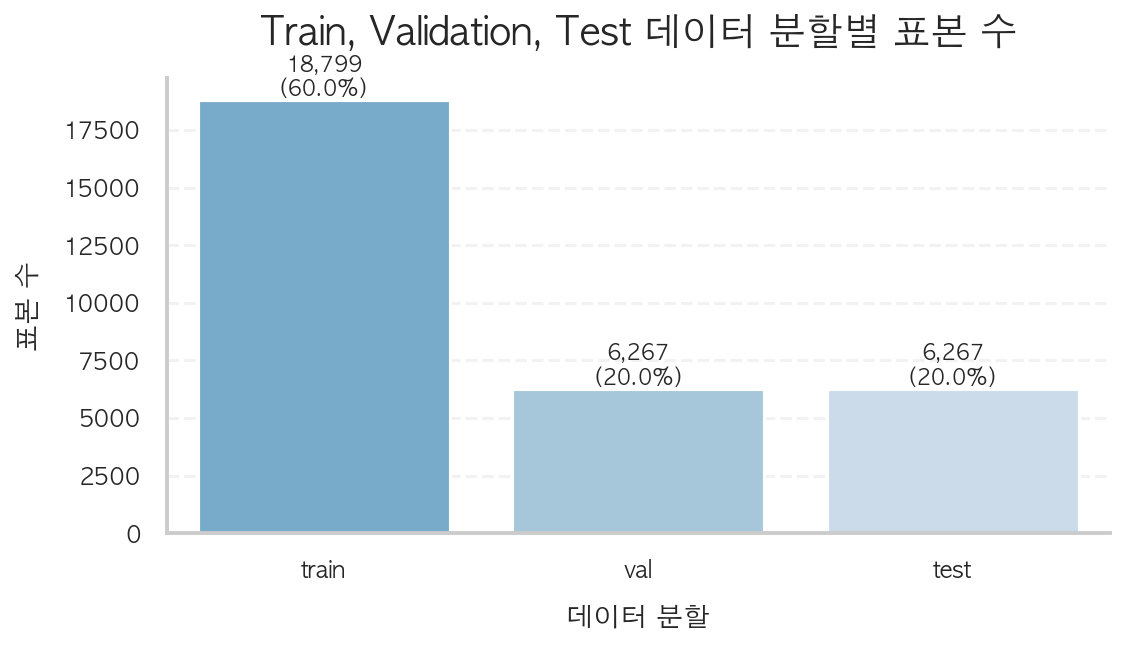

In [4]:
# 1. Split 크기 비교
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=eda_df, x="split", order=split_order, palette=["#6BAED6", "#9ECAE1", "#C6DBEF"])
set_axis_text(ax, "Train, Validation, Test 데이터 분할별 표본 수", "데이터 분할", "표본 수")
set_tick_orientation(ax, rotation=0)
apply_common_style(ax)
add_vertical_labels(ax, total=len(eda_df))
save_fig("01_split_sizes.png")

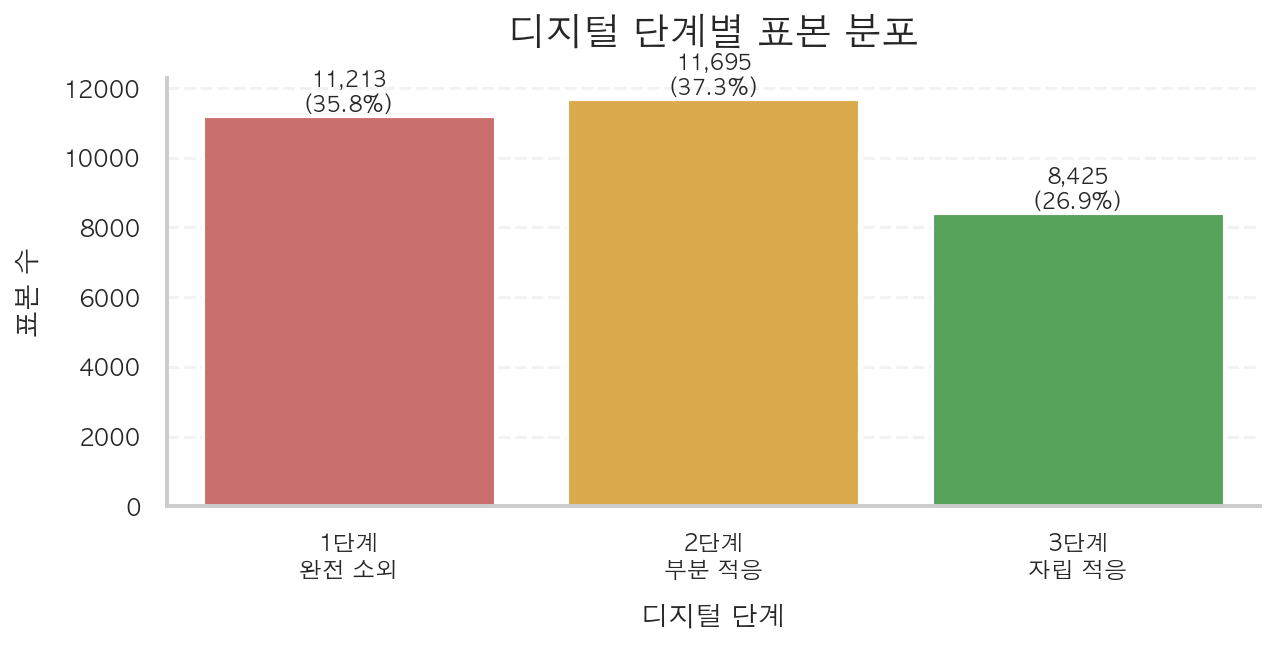

In [5]:
# 2. Digital stage 분포
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=eda_df, x="stage_label", order=STAGE_ORDER, palette=STAGE_PALETTE)
set_axis_text(ax, "디지털 단계별 표본 분포", "디지털 단계", "표본 수")
ax.set_xticklabels([STAGE_DISPLAY[s] for s in STAGE_ORDER])
set_tick_orientation(ax, rotation=0)
apply_common_style(ax)
add_vertical_labels(ax, total=len(eda_df))
save_fig("02_stage_distribution.png")

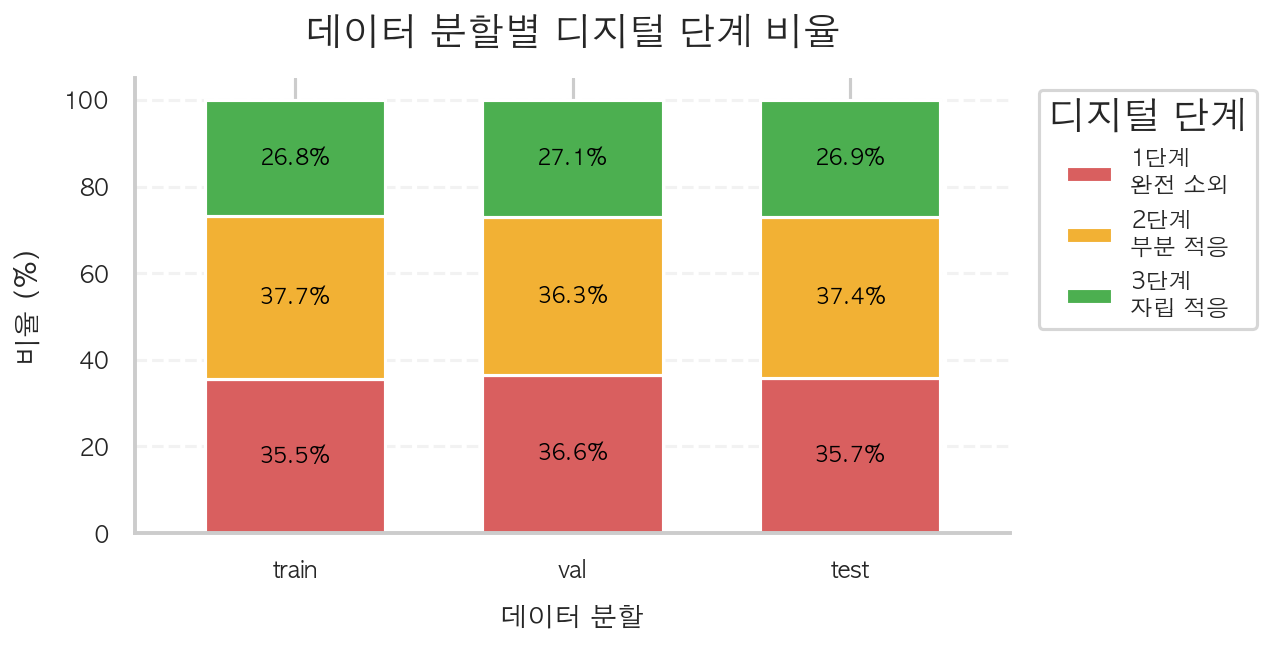

In [6]:
# 3. Split별 stage 비율 비교
split_stage_pct = pd.crosstab(eda_df["split"], eda_df["stage_label"], normalize="index").reindex(split_order)[STAGE_ORDER] * 100
split_stage_pct.columns = [STAGE_DISPLAY[c] for c in split_stage_pct.columns]

ax = split_stage_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    color=STAGE_PALETTE,
    edgecolor="white",
    width=0.65,
)
set_axis_text(ax, "데이터 분할별 디지털 단계 비율", "데이터 분할", "비율 (%)")
set_tick_orientation(ax, rotation=0)
ax.legend(title="디지털 단계", bbox_to_anchor=(1.02, 1), loc="upper left")
apply_common_style(ax)
for container in ax.containers:
    labels = []
    for value in container.datavalues:
        labels.append(f"{value:.1f}%" if value >= 8 else "")
    ax.bar_label(container, labels=labels, label_type="center", fontsize=10, fontweight="bold", color="black")
save_fig("03_stage_by_split_ratio.png")

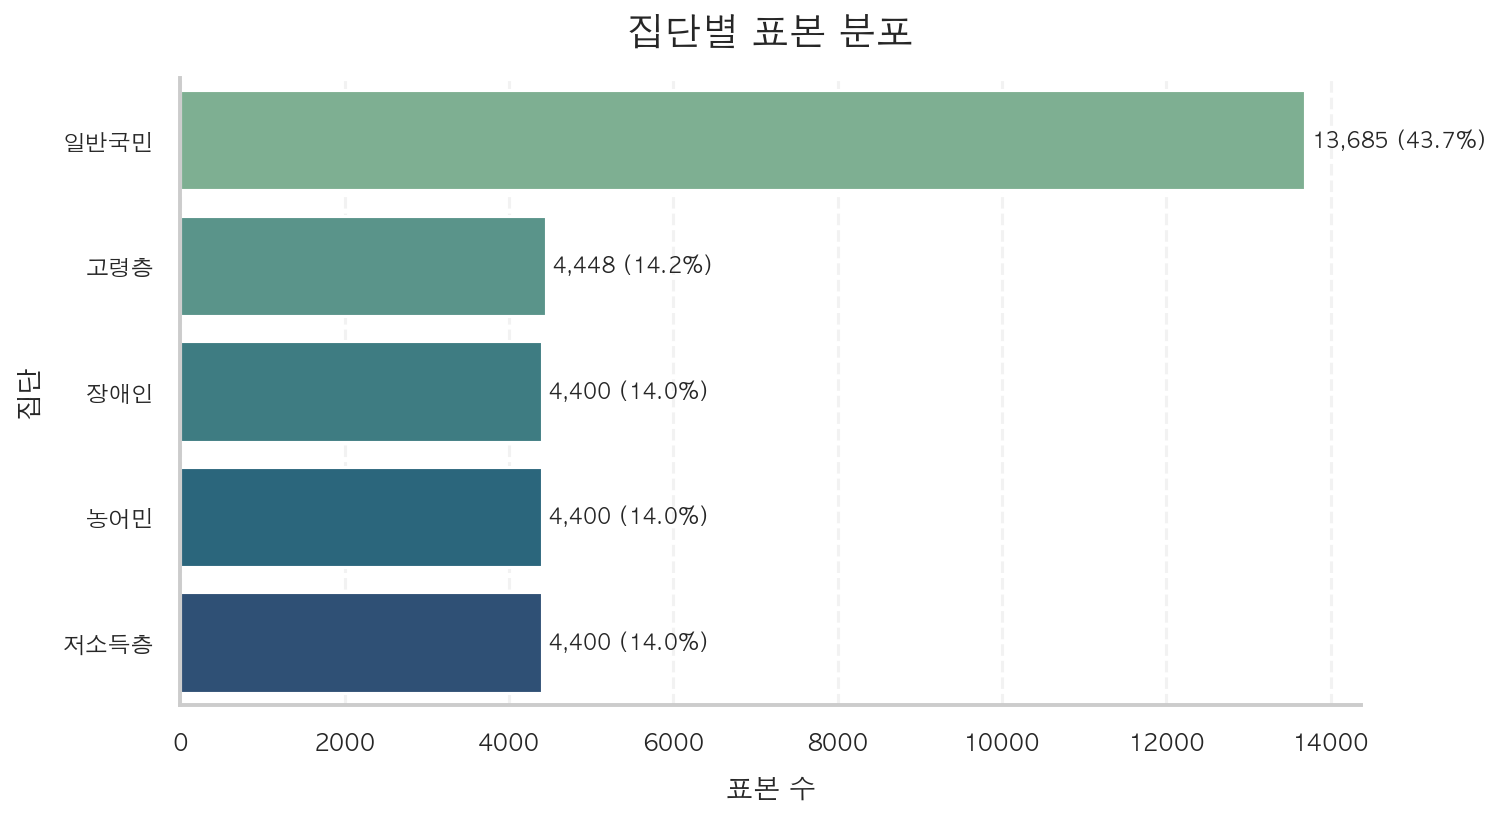

In [7]:
# 4. GROUP별 표본 분포
plt.figure(figsize=(10.5, 6.2))
ax = sns.countplot(data=eda_df, y="GROUP", order=group_order, palette="crest")
set_axis_text(ax, "집단별 표본 분포", "표본 수", "집단")
apply_common_style(ax, grid_axis="x")
add_horizontal_labels(ax, total=len(eda_df))
save_fig("04_group_distribution.png")

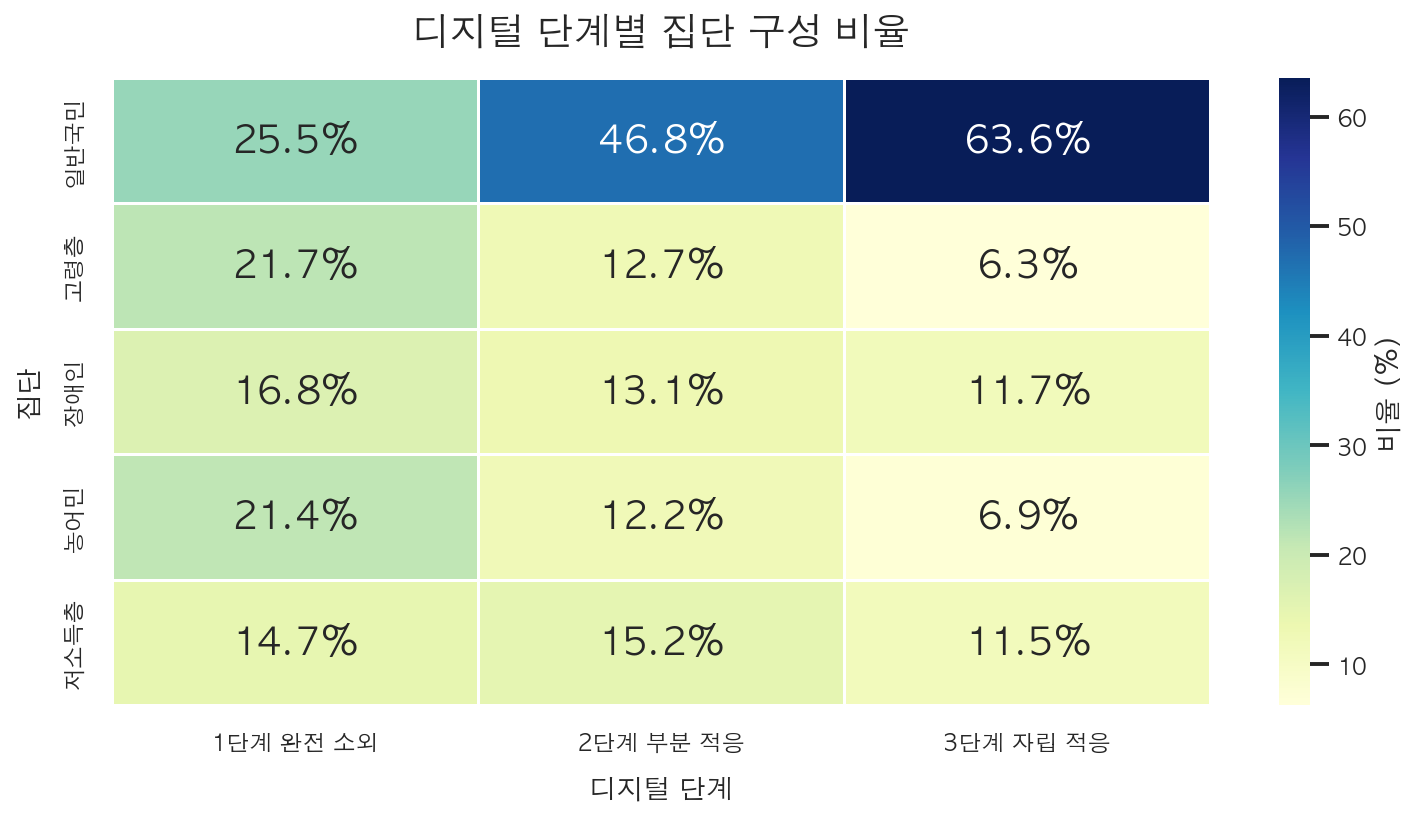

In [8]:
# 5. Stage별 GROUP 구성 비율 히트맵
group_stage_pct = pd.crosstab(eda_df["GROUP"], eda_df["stage_label"], normalize="columns") * 100
group_stage_pct = group_stage_pct.loc[group_order, STAGE_ORDER]
group_stage_pct.columns = [STAGE_DISPLAY[c].replace("\n", " ") for c in group_stage_pct.columns]

annot_text = format_percent_annotations(group_stage_pct)

plt.figure(figsize=(10.5, 6.2))
ax = sns.heatmap(group_stage_pct, annot=annot_text, fmt="", cmap="YlGnBu", linewidths=0.5, cbar_kws={"label": "비율 (%)"})
set_axis_text(ax, "디지털 단계별 집단 구성 비율", "디지털 단계", "집단")
save_fig("05_group_percentage_within_stage_heatmap.png")

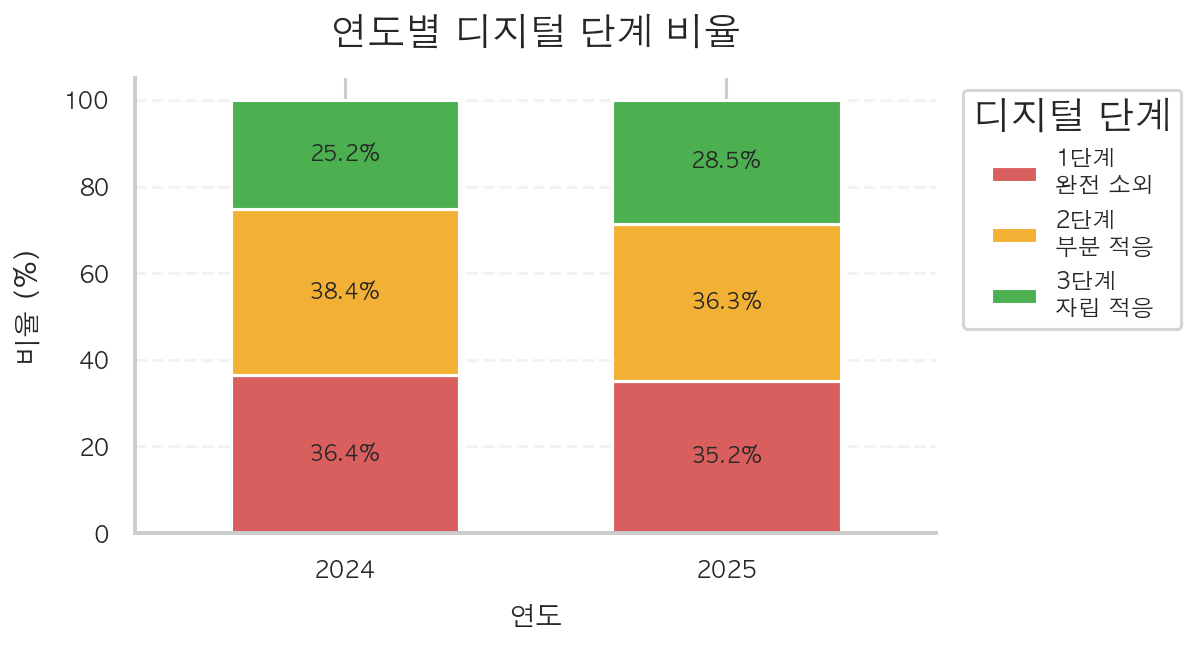

In [9]:
# 6. YEAR별 stage 비율 비교
year_stage_pct = pd.crosstab(eda_df["YEAR"], eda_df["stage_label"], normalize="index").sort_index()[STAGE_ORDER] * 100
year_stage_pct.columns = [STAGE_DISPLAY[c] for c in year_stage_pct.columns]

ax = year_stage_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8.5, 5),
    color=STAGE_PALETTE,
    edgecolor="white",
    width=0.6,
)
set_axis_text(ax, "연도별 디지털 단계 비율", "연도", "비율 (%)")
set_tick_orientation(ax, rotation=0)
ax.legend(title="디지털 단계", bbox_to_anchor=(1.02, 1), loc="upper left")
apply_common_style(ax)
for container in ax.containers:
    labels = []
    for value in container.datavalues:
        labels.append(f"{value:.1f}%" if value >= 8 else "")
    ax.bar_label(container, labels=labels, label_type="center", fontsize=10, fontweight="bold")
save_fig("06_stage_by_year_ratio.png")

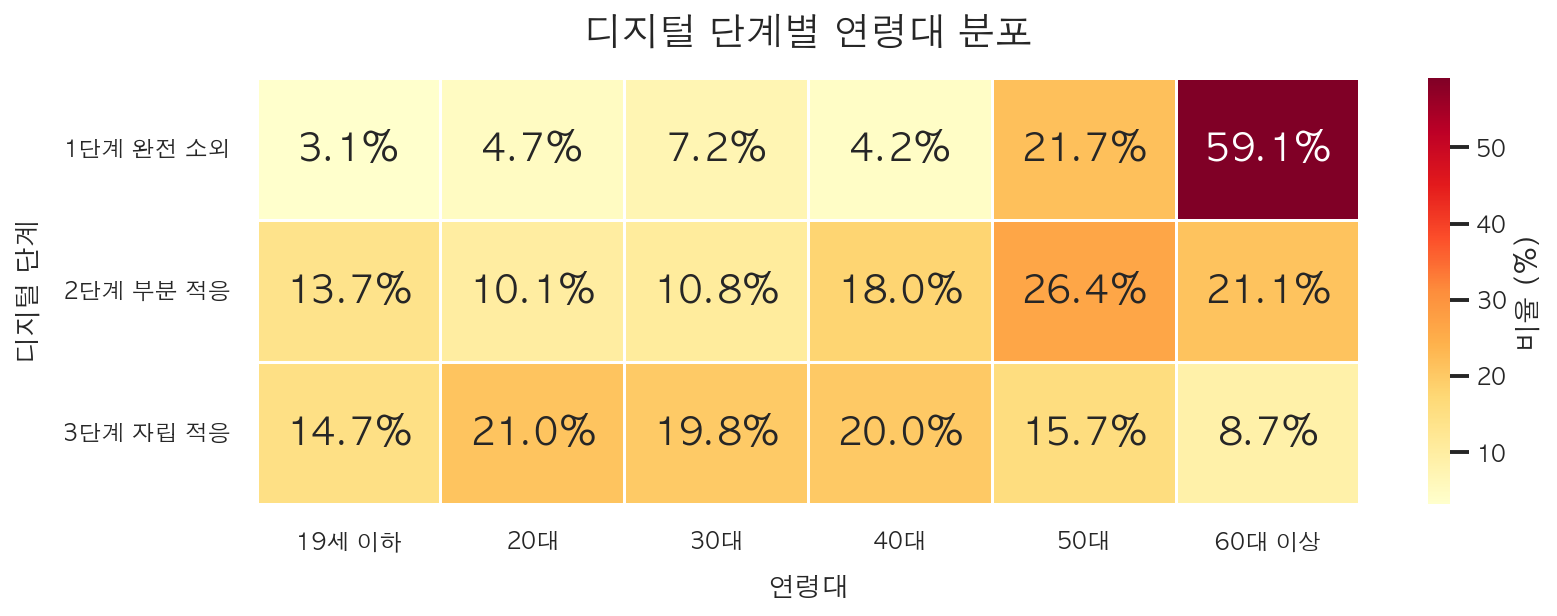

In [10]:
# 7. Stage별 연령대 분포
age_pct = pd.crosstab(eda_df["stage_label"], eda_df["연령대"], normalize="index").reindex(STAGE_ORDER)[AGE_ORDER] * 100
age_pct.index = [STAGE_DISPLAY[s].replace("\n", " ") for s in age_pct.index]

plt.figure(figsize=(11.5, 4.8))
ax = plt.gca()
plot_distribution_heatmap(ax, age_pct, "디지털 단계별 연령대 분포", "연령대", "디지털 단계", cmap="YlOrRd", rotation=0)
save_fig("07_age_distribution_by_stage.png")


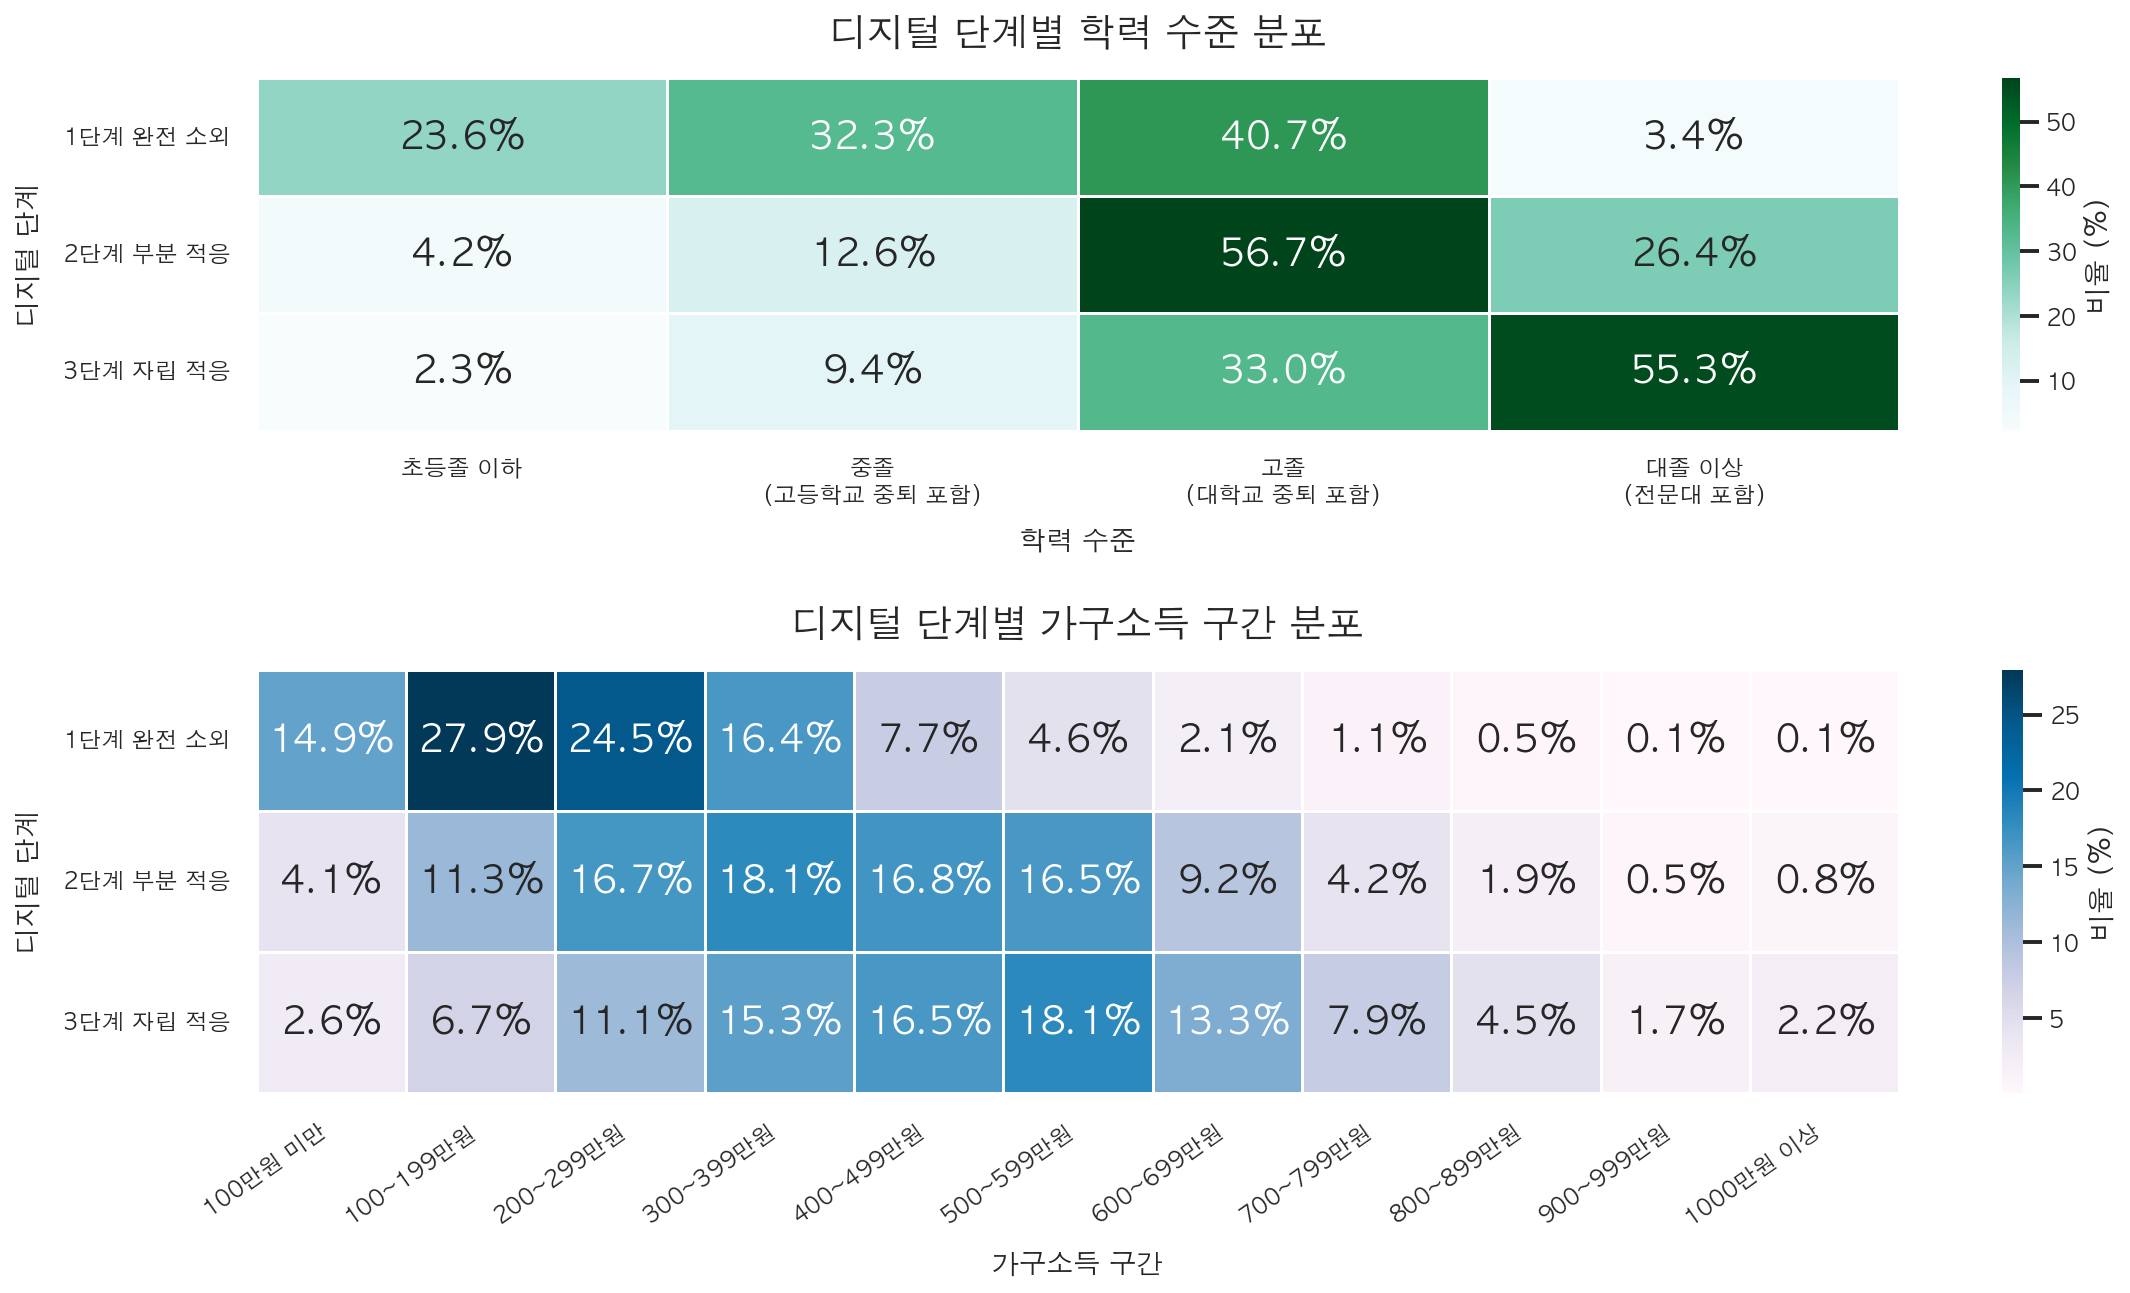

In [11]:
# 8. Stage별 학력 / 가구소득 구간 분포
edu_pct = pd.crosstab(eda_df["stage_label"], eda_df["학력수준"], normalize="index").reindex(STAGE_ORDER)[EDU_ORDER] * 100
income_pct = pd.crosstab(eda_df["stage_label"], eda_df["가구소득구간"], normalize="index").reindex(STAGE_ORDER)[INCOME_ORDER] * 100

edu_pct.index = [STAGE_DISPLAY[s].replace("\n", " ") for s in edu_pct.index]
income_pct.index = [STAGE_DISPLAY[s].replace("\n", " ") for s in income_pct.index]

fig, axes = plt.subplots(2, 1, figsize=(16, 9.5), gridspec_kw={"height_ratios": [1, 1.2]})
plot_distribution_heatmap(axes[0], edu_pct, "디지털 단계별 학력 수준 분포", "학력 수준", "디지털 단계", cmap="BuGn", rotation=0)
plot_distribution_heatmap(axes[1], income_pct, "디지털 단계별 가구소득 구간 분포", "가구소득 구간", "디지털 단계", cmap="PuBu", rotation=35)
save_fig("08_education_income_distribution_by_stage.png")


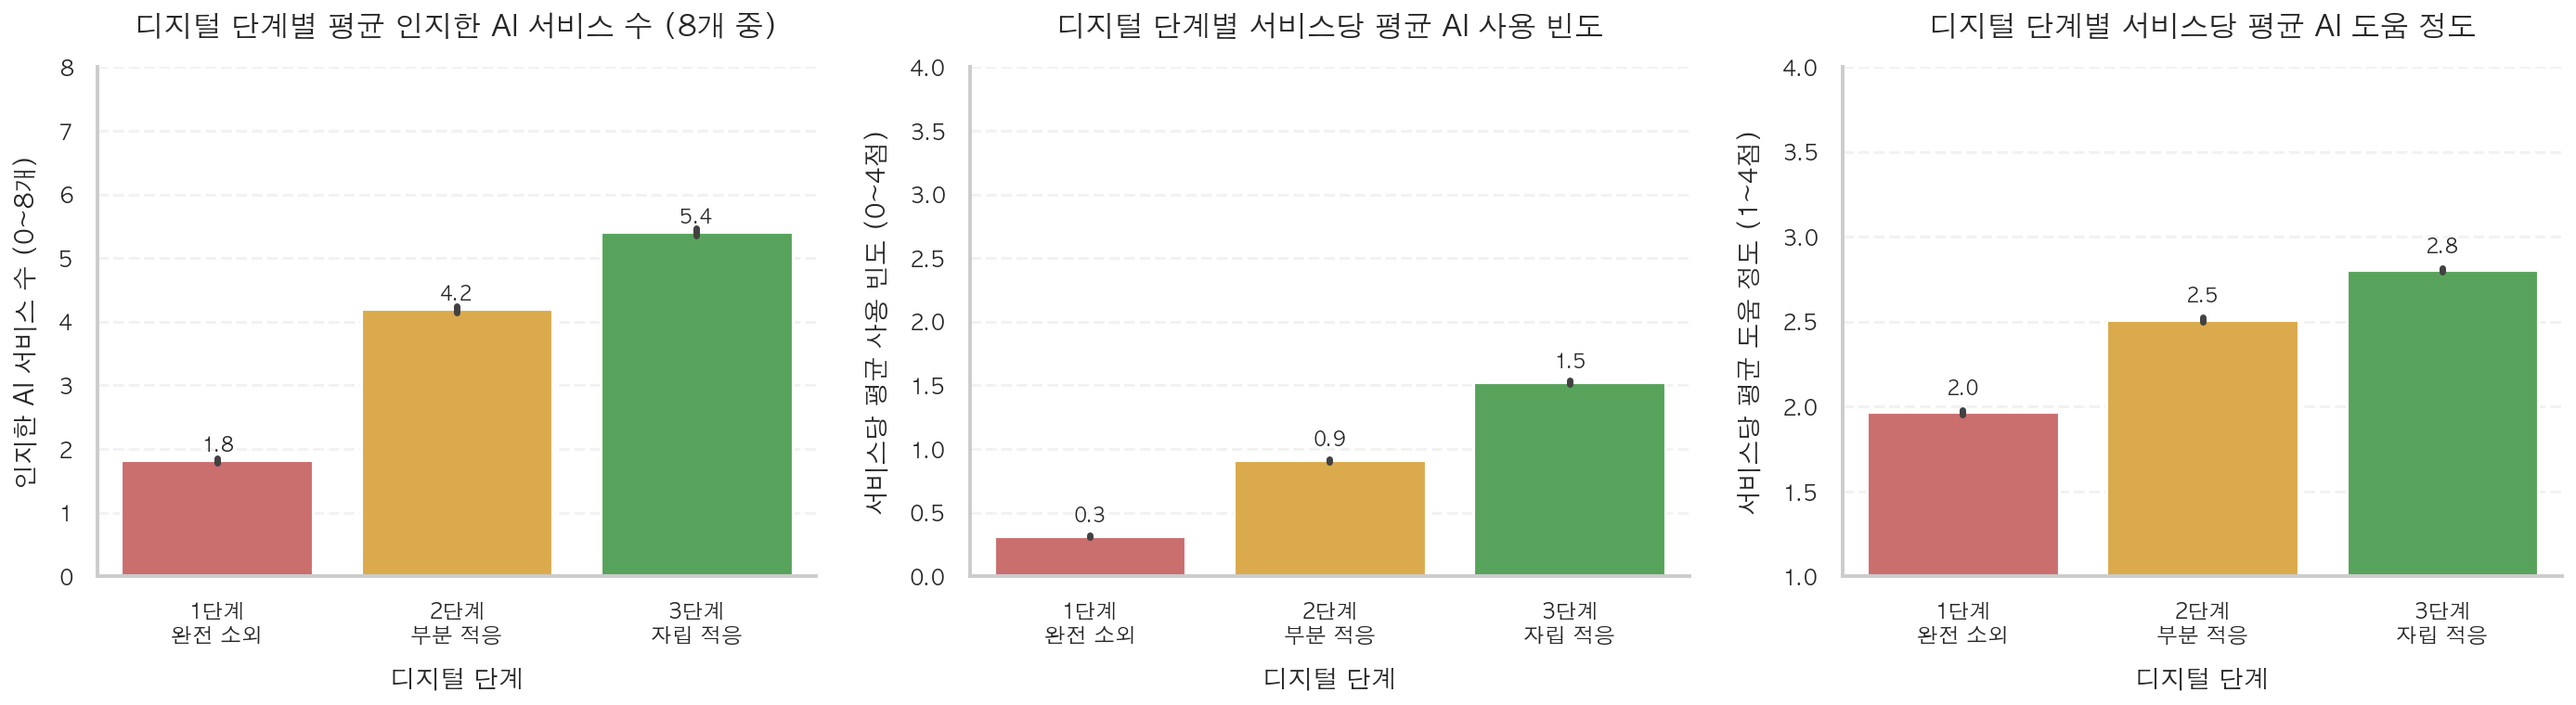

In [12]:
# 9. Stage별 평균 AI 변수 비교
ai_cols = ["인지한_AI_서비스_수", "서비스당_평균_AI_사용빈도", "서비스당_평균_AI_도움정도"]
ai_titles = [
    "디지털 단계별 평균 인지한 AI 서비스 수 (8개 중)",
    "디지털 단계별 서비스당 평균 AI 사용 빈도",
    "디지털 단계별 서비스당 평균 AI 도움 정도",
]
ai_ylabels = [
    "인지한 AI 서비스 수 (0~8개)",
    "서비스당 평균 사용 빈도 (0~4점)",
    "서비스당 평균 도움 정도 (1~4점)",
]
ai_ylims = [(0, 8), (0, 4), (1, 4)]

fig, axes = plt.subplots(1, 3, figsize=(19, 5.8))

for ax, col, title, ylabel, ylim in zip(axes, ai_cols, ai_titles, ai_ylabels, ai_ylims):
    sns.barplot(data=eda_df, x="stage_label", y=col, order=STAGE_ORDER, palette=STAGE_PALETTE, ax=ax)
    set_axis_text(ax, title, "디지털 단계", ylabel, title_size=15)
    ax.set_xticklabels([STAGE_DISPLAY[s] for s in STAGE_ORDER])
    ax.set_ylim(*ylim)
    set_tick_orientation(ax, rotation=0)
    apply_common_style(ax)
    add_bar_values(ax, decimals=1)

save_fig("09_ai_variables_by_stage.png")


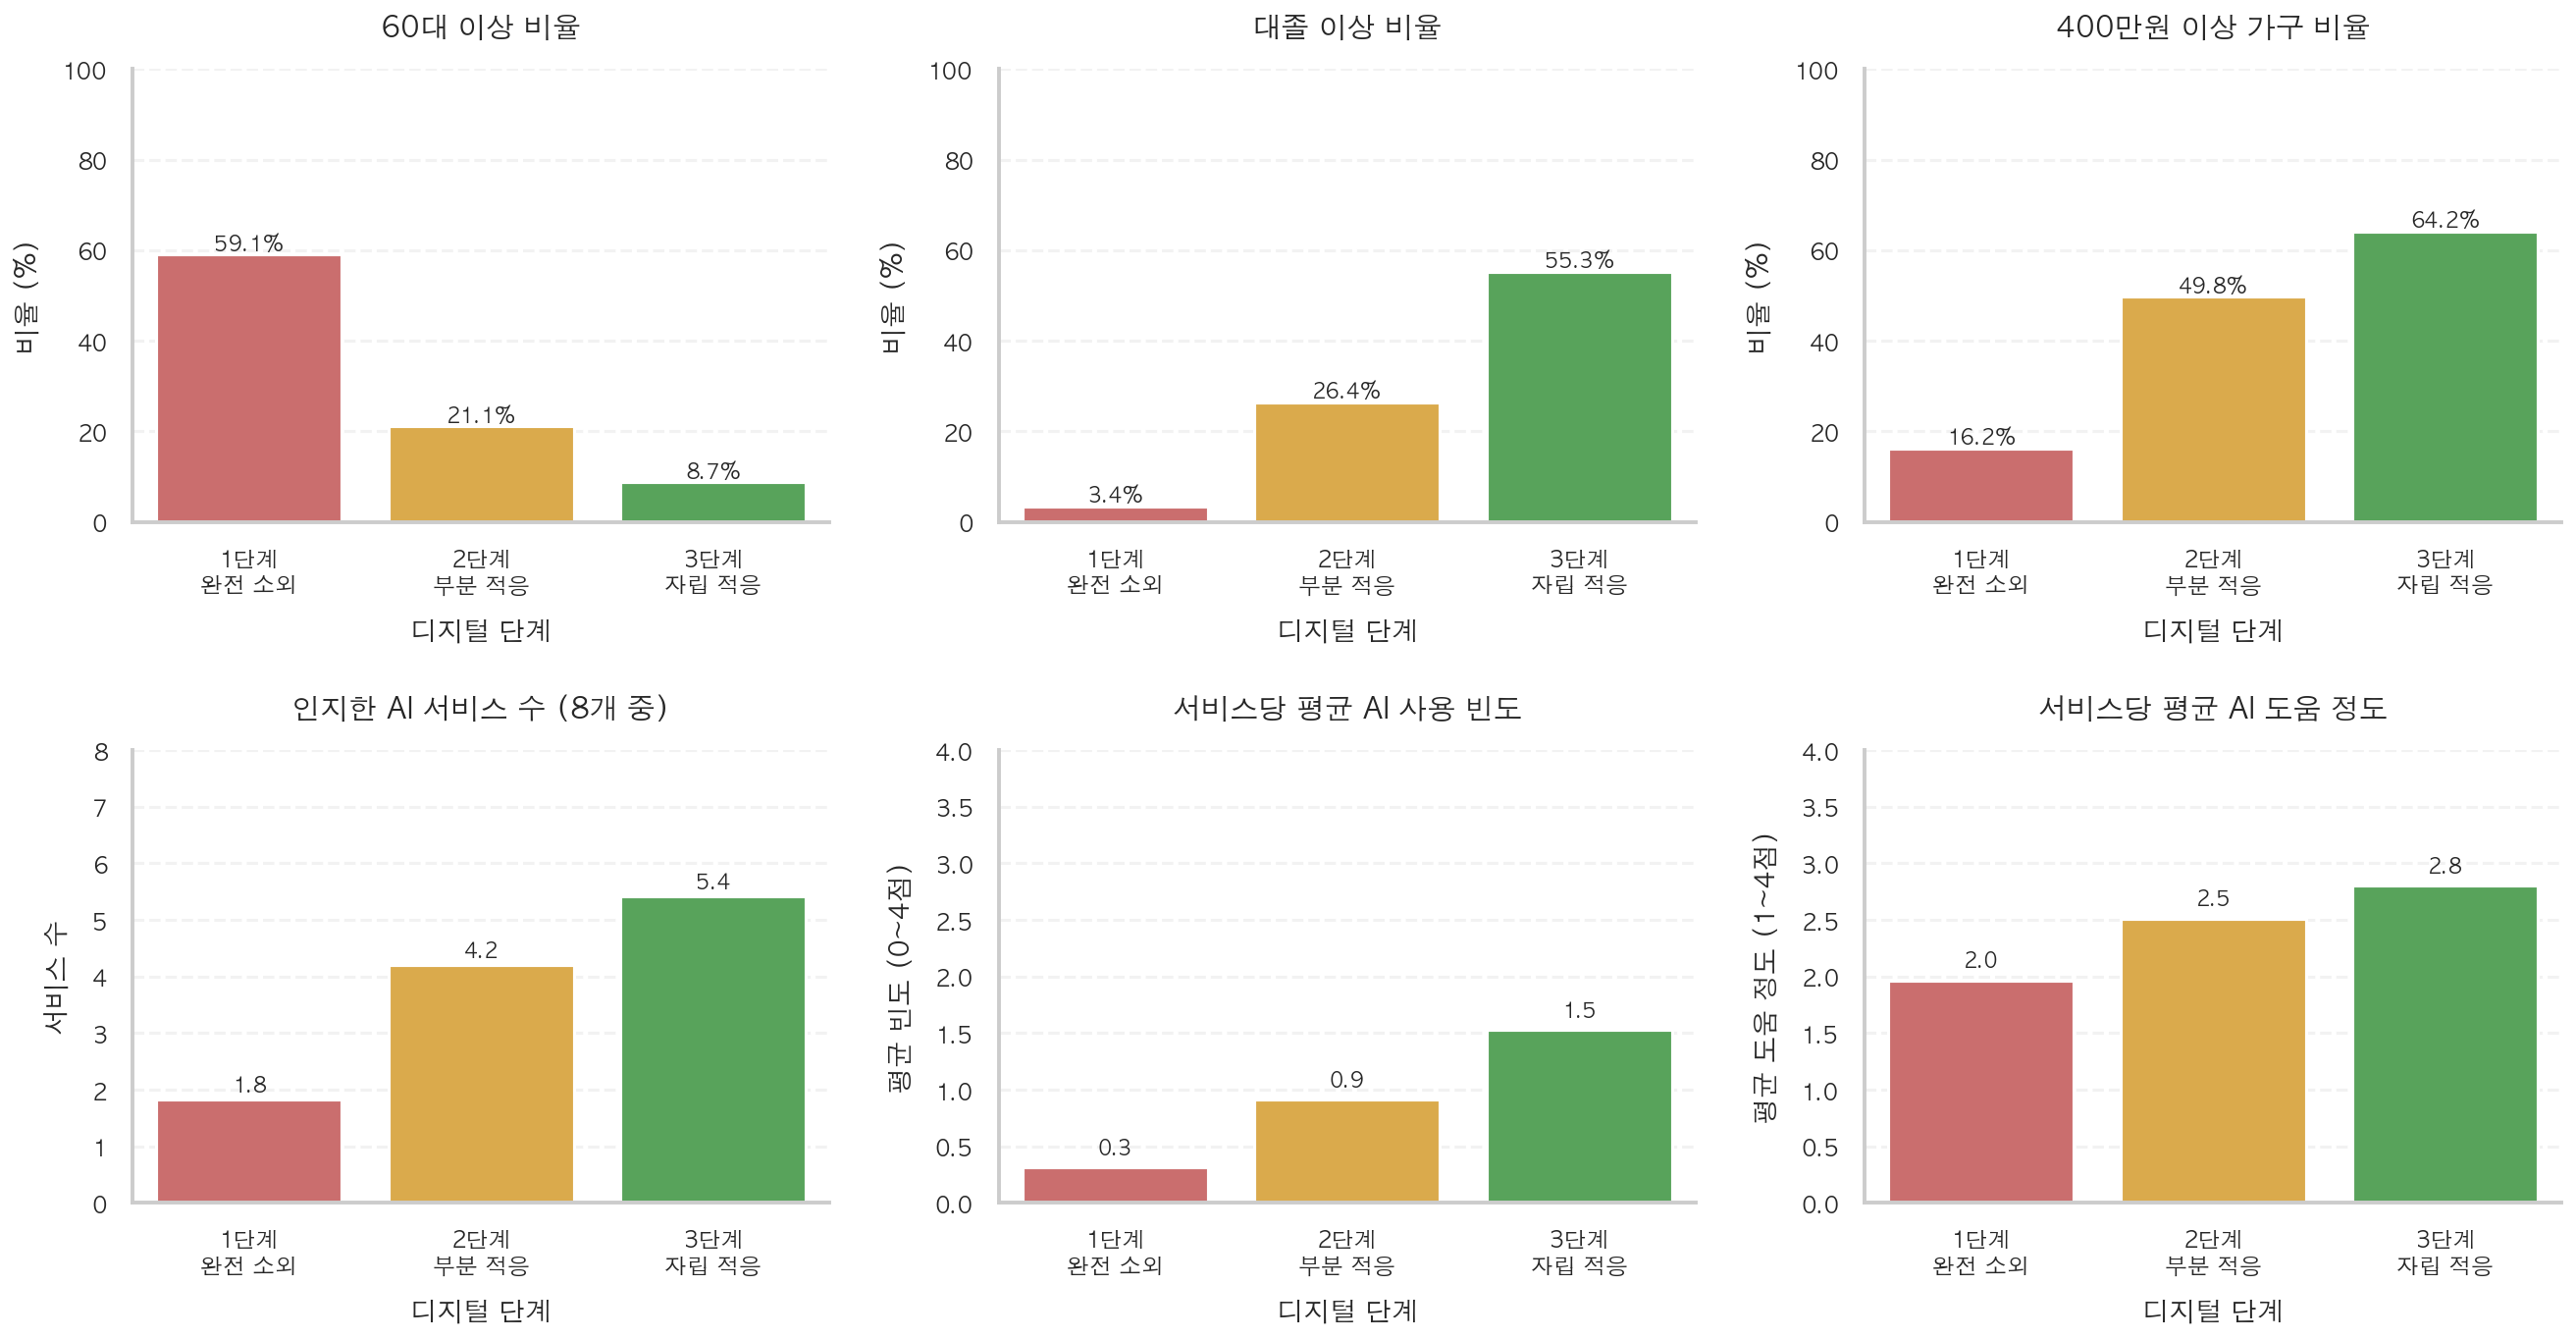

In [13]:
# 10. 디지털 단계별 핵심 지표 요약
metric_specs = [
    {
        "title": "60대 이상 비율",
        "series": eda_df.groupby("stage_label")["연령대"].apply(lambda s: (s == "60대 이상").mean() * 100),
        "ylabel": "비율 (%)",
        "ylim": (0, 100),
        "suffix": "%",
    },
    {
        "title": "대졸 이상 비율",
        "series": eda_df.groupby("stage_label")["학력수준"].apply(lambda s: (s == "대졸 이상\n(전문대 포함)").mean() * 100),
        "ylabel": "비율 (%)",
        "ylim": (0, 100),
        "suffix": "%",
    },
    {
        "title": "400만원 이상 가구 비율",
        "series": eda_df.groupby("stage_label")["가구소득구간"].apply(lambda s: s.isin(["400~499만원", "500~599만원", "600~699만원", "700~799만원", "800~899만원", "900~999만원", "1000만원 이상"]).mean() * 100),
        "ylabel": "비율 (%)",
        "ylim": (0, 100),
        "suffix": "%",
    },
    {
        "title": "인지한 AI 서비스 수 (8개 중)",
        "series": eda_df.groupby("stage_label")["인지한_AI_서비스_수"].mean(),
        "ylabel": "서비스 수",
        "ylim": (0, 8),
        "suffix": "",
    },
    {
        "title": "서비스당 평균 AI 사용 빈도",
        "series": eda_df.groupby("stage_label")["서비스당_평균_AI_사용빈도"].mean(),
        "ylabel": "평균 빈도 (0~4점)",
        "ylim": (0, 4),
        "suffix": "",
    },
    {
        "title": "서비스당 평균 AI 도움 정도",
        "series": eda_df.groupby("stage_label")["서비스당_평균_AI_도움정도"].mean(),
        "ylabel": "평균 도움 정도 (1~4점)",
        "ylim": (0, 4),
        "suffix": "",
    },
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, spec in zip(axes.flatten(), metric_specs):
    metric_df = spec["series"].reindex(STAGE_ORDER).reset_index()
    metric_df.columns = ["stage_label", "value"]
    sns.barplot(data=metric_df, x="stage_label", y="value", order=STAGE_ORDER, palette=STAGE_PALETTE, ax=ax)
    ax.set_xticklabels([STAGE_DISPLAY[s] for s in STAGE_ORDER])
    ax.set_ylim(*spec["ylim"])
    set_axis_text(ax, spec["title"], "디지털 단계", spec["ylabel"], title_size=14)
    set_tick_orientation(ax, rotation=0)
    apply_common_style(ax)
    add_bar_values(ax, decimals=1, suffix=spec["suffix"])

save_fig("10_stage_key_indicator_summary.png")


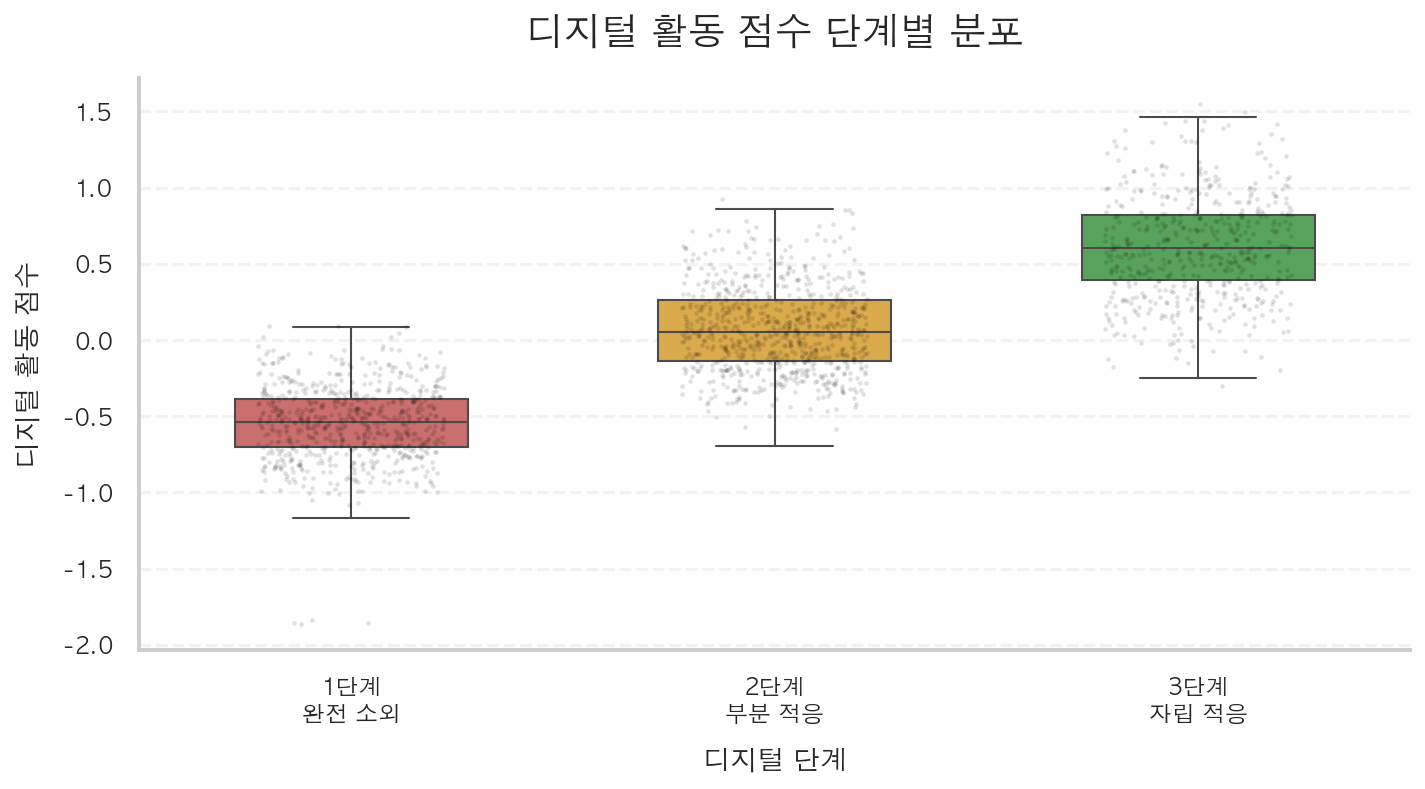

In [14]:
# 11. 디지털 활동 점수 단계별 분포
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=eda_df, x="stage_label", y="digital_activity_score", order=STAGE_ORDER, palette=STAGE_PALETTE, width=0.55, showfliers=False)
sns.stripplot(data=eda_df.sample(min(2000, len(eda_df)), random_state=42), x="stage_label", y="digital_activity_score", order=STAGE_ORDER, color="black", alpha=0.12, size=2.2, jitter=0.22, ax=ax)
ax.set_xticklabels([STAGE_DISPLAY[s] for s in STAGE_ORDER])
set_axis_text(ax, "디지털 활동 점수 단계별 분포", "디지털 단계", "디지털 활동 점수")
set_tick_orientation(ax, rotation=0)
apply_common_style(ax)
save_fig("11_digital_activity_score_boxplot.png")


## 변수 해석 

- 원천 데이터의 `변수값` 시트를 확인해 `연령`, `학력`, `가구소득`은 실제 범주명으로 바꿨습니다.
- `연령`은 `19세 이하`, `20대`, `30대`, `40대`, `50대`, `60대 이상`으로 해석합니다.
- `학력`은 `초등졸 이하`, `중졸`, `고졸`, `대졸 이상` 범주로 해석합니다.
- `가구소득`은 `100만원 미만`부터 `1000만원 이상`까지의 소득 구간으로 해석합니다.
- `인지한_AI_서비스_수`는 `교육/학습`, `주거 편의`, `커뮤니케이션/친교`, `미디어`, `금융`, `교통`, `헬스케어`, `AI기반 대화형 정보검색`의 **8개 서비스 중 몇 개를 알고 있는지**를 뜻합니다.
- `서비스당_평균_AI_사용빈도`는 위 8개 서비스에 대한 사용 빈도를 평균 낸 값입니다. `0=미사용/미인지`, `1=전혀 없음`, `2=별로 없음`, `3=가끔 있음`, `4=자주 있음`으로 해석합니다.
- `서비스당_평균_AI_도움정도`는 위 8개 서비스에 대한 도움 정도를 평균 낸 값입니다. `1=전혀 그렇지 않다`, `2=그렇지 않은 편이다`, `3=그런 편이다`, `4=매우 그렇다`로 해석합니다.
- `digital_activity_score`는 레이블 설계 노트북에서 사용한 핵심 종합 지표로, 기기 접근성, 기본 역량, 사용 시간, 서비스 활용, AI 관련 지표를 표준화해 평균 낸 값입니다.
